In [1]:
from pathlib import Path

pasta = Path('data/phisionet_data/S001')  # Ajuste o caminho conforme necessário

# Lista dos sufixos que queremos filtrar
sufixos_desejados = ['R04', 'R08', 'R12']

# Iterar sobre os arquivos e filtrar
for arquivo in pasta.glob('S001R*.edf*'):  # *.edf* pega tanto .edf quanto .edf.event
    if any(sufixo in arquivo.name for sufixo in sufixos_desejados):
        print(arquivo)

data\phisionet_data\S001\S001R04.edf
data\phisionet_data\S001\S001R04.edf.event
data\phisionet_data\S001\S001R08.edf
data\phisionet_data\S001\S001R08.edf.event
data\phisionet_data\S001\S001R12.edf
data\phisionet_data\S001\S001R12.edf.event



Processando S001R04.edf...


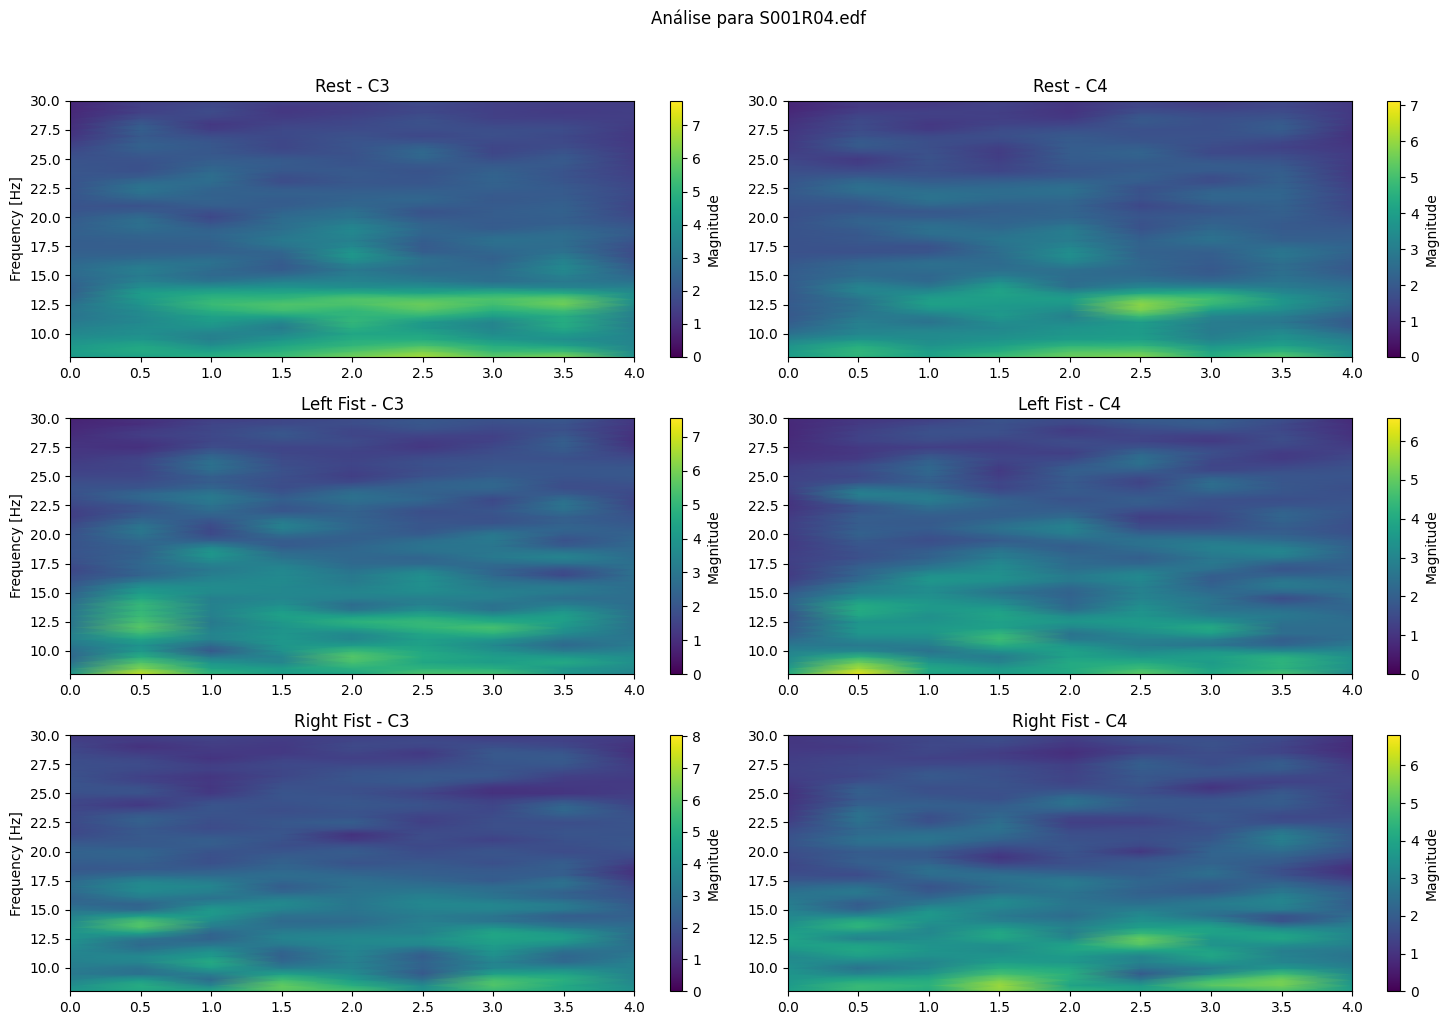

Laterality Index (Left Fist): 0.09
Laterality Index (Right Fist): 0.01
--------------------------------------------------

Processando S001R08.edf...


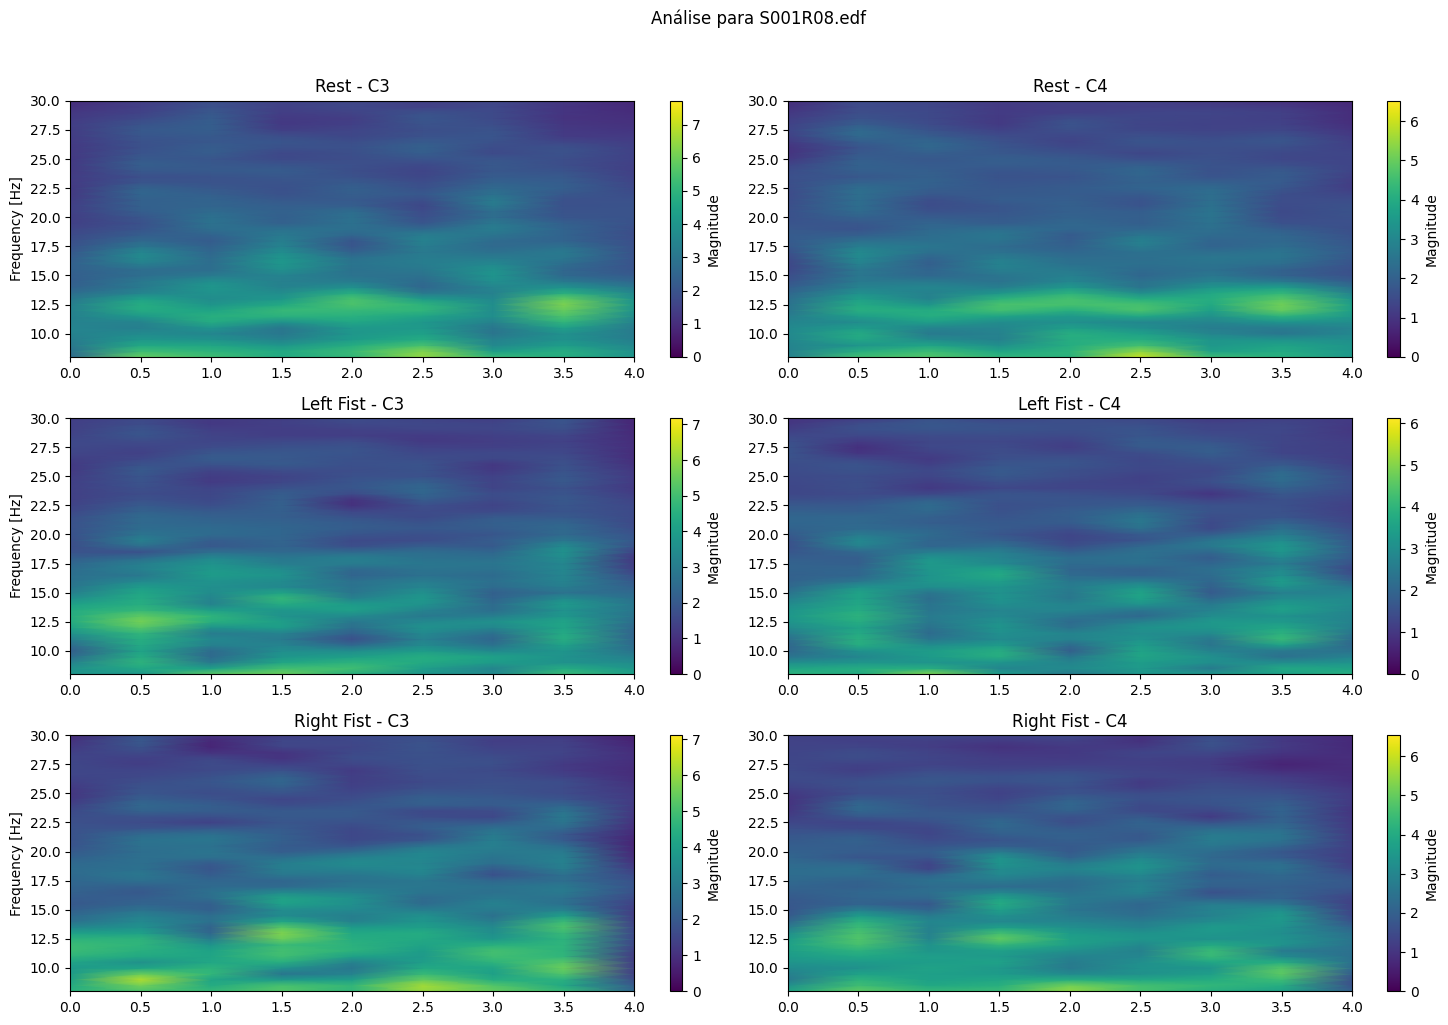

Laterality Index (Left Fist): 0.09
Laterality Index (Right Fist): 0.08
--------------------------------------------------

Processando S001R12.edf...


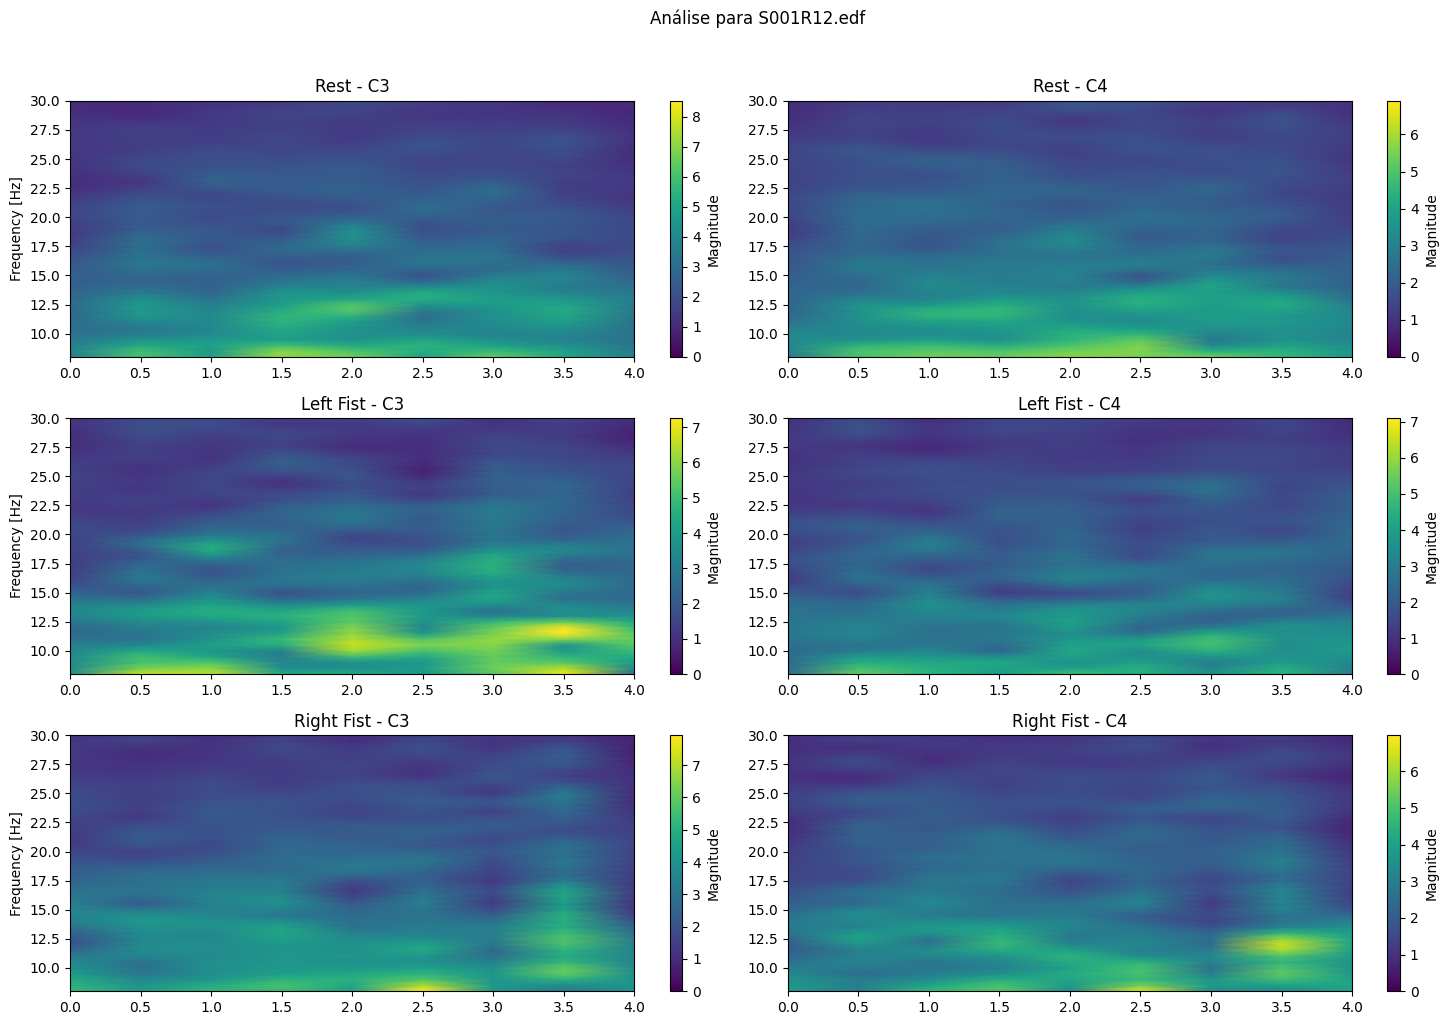

Laterality Index (Left Fist): 0.14
Laterality Index (Right Fist): 0.08
--------------------------------------------------


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt
from pyedflib import EdfReader
from pathlib import Path

# Funções de filtro (mantidas as mesmas)
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def notch_filter(data, notch_freq, fs, quality=30):
    nyquist = 0.5 * fs
    freq = notch_freq / nyquist
    b, a = butter(2, [freq - 0.5/quality, freq + 0.5/quality], btype='bandstop')
    return filtfilt(b, a, data)

def compute_epoch_stft(data, events, event_type, tmin=0, tmax=4, fs=160):
    event_samples = [e[0] for e in events if e[2] == event_type]
    stft_results = []
    
    for sample in event_samples:
        start = sample + int(tmin * fs)
        end = sample + int(tmax * fs)
        epoch = data[start:end]
        
        f, t, Zxx = signal.stft(epoch, fs=fs, window='hann',
                               nperseg=int(fs * 1.0), noverlap=int(fs * 0.5), 
                               nfft=int(fs * 2.0))
        stft_results.append(np.abs(Zxx))
        
    avg_stft = np.mean(stft_results, axis=0)
    return f, t, avg_stft

def laterality_index(c3_power, c4_power):
    return (c3_power - c4_power) / (c3_power + c4_power + 1e-10)

# Processar arquivos R04, R08 e R12
pasta = Path('data/phisionet_data/S001')
registros = ['R04', 'R08', 'R12']
event_dict = {'T0': 'Rest', 'T1': 'Left Fist', 'T2': 'Right Fist'}

for registro in registros:
    # Encontrar arquivo .edf correspondente
    edf_file = next(pasta.glob(f'*{registro}.edf'))
    print(f"\nProcessando {edf_file.name}...")
    
    # Carregar dados EDF usando EdfReader
    reader = EdfReader(str(edf_file))
    
    # Obter informações dos sinais
    n_channels = reader.signals_in_file
    signal_labels = reader.getSignalLabels()
    fs = reader.getSampleFrequency(0)  # Assumindo mesma taxa de amostragem para todos os canais
    signals = np.array([reader.readSignal(i) for i in range(n_channels)])
    
    # Obter canais C3 e C4
    c3_idx = signal_labels.index('C3..')
    c4_idx = signal_labels.index('C4..')
    c3_signal = signals[c3_idx, :]
    c4_signal = signals[c4_idx, :]
    
    # Ler anotações diretamente do arquivo EDF
    annotations = reader.readAnnotations()
    reader.close()
    
    # Converter anotações para formato de eventos (amostras em vez de segundos)
    events = []
    for onset, duration, description in zip(annotations[0], annotations[1], annotations[2]):
        events.append([int(onset * fs), 0, description])
    
    # Aplicar filtros
    c3_filtered = notch_filter(bandpass_filter(c3_signal, 0.5, 40, fs), 50, fs)
    c4_filtered = notch_filter(bandpass_filter(c4_signal, 0.5, 40, fs), 50, fs)
    
    # Processar condições
    conditions = ['T0', 'T1', 'T2']
    results = {}
    
    for cond in conditions:
        f, t, c3_stft = compute_epoch_stft(c3_filtered, events, cond)
        _, _, c4_stft = compute_epoch_stft(c4_filtered, events, cond)
        
        results[cond] = {
            'frequencies': f,
            'times': t,
            'C3': c3_stft,
            'C4': c4_stft
        }
    
    # Visualização
    plt.figure(figsize=(15, 10))
    plt.suptitle(f'Análise para {edf_file.name}', y=1.02)
    
    for i, cond in enumerate(conditions):
        # Plot C3
        plt.subplot(3, 2, i*2+1)
        plt.pcolormesh(results[cond]['times'], results[cond]['frequencies'], 
                      results[cond]['C3'], shading='gouraud', vmin=0, 
                      vmax=np.percentile(results[cond]['C3'], 95))
        plt.colorbar(label='Magnitude')
        plt.title(f'{event_dict[cond]} - C3')
        plt.ylabel('Frequency [Hz]')
        plt.ylim([8, 30])
        
        # Plot C4
        plt.subplot(3, 2, i*2+2)
        plt.pcolormesh(results[cond]['times'], results[cond]['frequencies'], 
                      results[cond]['C4'], shading='gouraud', vmin=0, 
                      vmax=np.percentile(results[cond]['C4'], 95))
        plt.colorbar(label='Magnitude')
        plt.title(f'{event_dict[cond]} - C4')
        plt.ylim([8, 30])
    
    plt.tight_layout()
    plt.show()
    
    # Calcular Laterality Index
    mu_band = (results['T1']['frequencies'] >= 8) & (results['T1']['frequencies'] <= 13)
    movement_window = (results['T1']['times'] >= 1) & (results['T1']['times'] <= 3)
    
    li_left = laterality_index(
        np.mean(results['T1']['C3'][mu_band][:, movement_window]),
        np.mean(results['T1']['C4'][mu_band][:, movement_window])
    )
    
    li_right = laterality_index(
        np.mean(results['T2']['C3'][mu_band][:, movement_window]),
        np.mean(results['T2']['C4'][mu_band][:, movement_window])
    )
    
    print(f"Laterality Index (Left Fist): {li_left:.2f}")
    print(f"Laterality Index (Right Fist): {li_right:.2f}")
    print("-" * 50)

Distribuição das classes:
T0 (Repouso): 45
T1 (Mão esquerda): 23
T2 (Mão direita): 22

=== Random Forest ===
              precision    recall  f1-score   support

          T0       0.73      0.89      0.80         9
          T1       0.50      0.40      0.44         5
          T2       0.33      0.25      0.29         4

    accuracy                           0.61        18
   macro avg       0.52      0.51      0.51        18
weighted avg       0.58      0.61      0.59        18



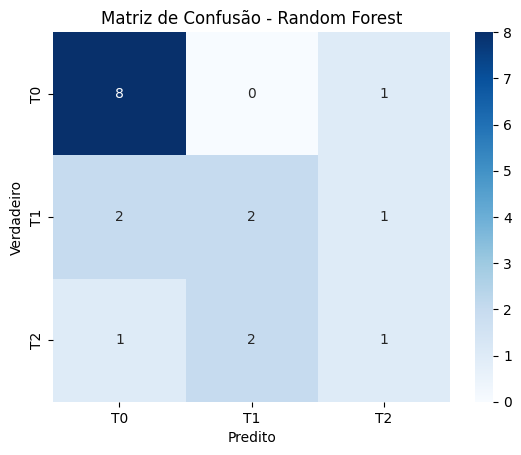


=== SVM ===
              precision    recall  f1-score   support

          T0       0.62      0.89      0.73         9
          T1       0.33      0.20      0.25         5
          T2       0.50      0.25      0.33         4

    accuracy                           0.56        18
   macro avg       0.48      0.45      0.44        18
weighted avg       0.51      0.56      0.51        18



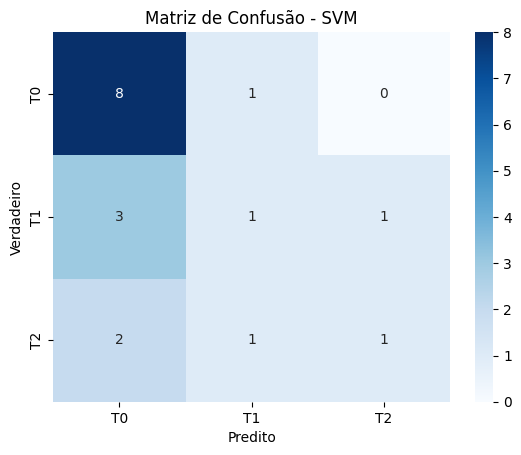

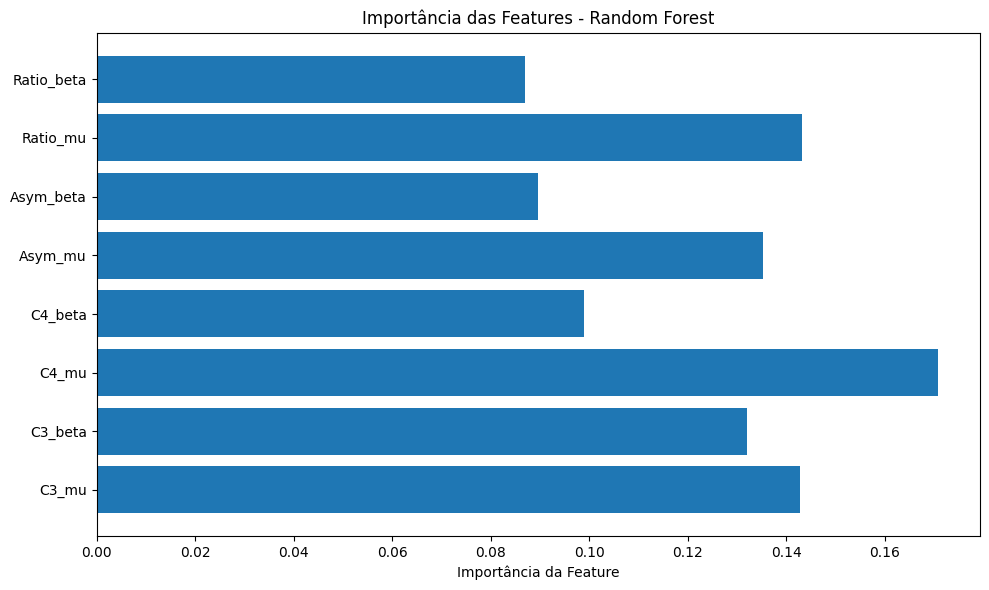

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pyedflib import EdfReader
from pathlib import Path
from scipy.signal import welch

# Configurações
FS = 160  # Frequência de amostragem
BANDS = {
    'mu': (8, 13),
    'beta': (13, 30)
}
EPOCH_DURATION = 4  # segundos
EVENTS = {'T0': 0, 'T1': 1, 'T2': 2}

def extract_features(signal, fs, bands):
    """Extrai features no domínio da frequência usando PSD"""
    freqs, psd = welch(signal, fs=fs, nperseg=fs*2)
    features = []
    for band, (low, high) in bands.items():
        band_mask = (freqs >= low) & (freqs <= high)
        features.append(np.log10(psd[band_mask].mean()))
    return np.array(features)

def process_file(file_path):
    """Processa um arquivo EDF e retorna features e labels"""
    reader = EdfReader(str(file_path))
    
    # Obter sinais
    signal_labels = reader.getSignalLabels()
    c3_idx = signal_labels.index('C3..')
    c4_idx = signal_labels.index('C4..')
    fs = reader.getSampleFrequency(c3_idx)
    signals = np.array([reader.readSignal(i) for i in range(reader.signals_in_file)])
    
    # Obter anotações
    annotations = reader.readAnnotations()
    reader.close()
    
    X, y = [], []
    
    for onset, duration, description in zip(*annotations):
        if description not in EVENTS:
            continue
            
        start = int(onset * fs)
        end = start + int(EPOCH_DURATION * fs)
        
        if end > signals.shape[1]:
            continue
            
        # Extrair features de C3 e C4
        c3_epoch = signals[c3_idx, start:end]
        c4_epoch = signals[c4_idx, start:end]
        
        # Aplicar filtros (opcional, pode ser feito antes)
        # c3_epoch = bandpass_filter(c3_epoch, 0.5, 40, fs)
        # c4_epoch = bandpass_filter(c4_epoch, 0.5, 40, fs)
        
        # Extrair features
        c3_features = extract_features(c3_epoch, fs, BANDS)
        c4_features = extract_features(c4_epoch, fs, BANDS)
        
        # Features adicionais: assimetria e razão entre bandas
        asymmetry = c3_features - c4_features
        band_ratio = c3_features / (c4_features + 1e-10)
        
        # Combinar todas as features
        full_features = np.concatenate([
            c3_features, 
            c4_features,
            asymmetry,
            band_ratio
        ])
        
        X.append(full_features)
        y.append(EVENTS[description])
    
    return np.array(X), np.array(y)

# Carregar e processar todos os arquivos
pasta = Path('data/phisionet_data/S001')
registros = ['R04', 'R08', 'R12']

X_all, y_all = [], []
for registro in registros:
    edf_file = next(pasta.glob(f'*{registro}.edf'))
    X, y = process_file(edf_file)
    X_all.append(X)
    y_all.append(y)

X = np.concatenate(X_all)
y = np.concatenate(y_all)

# Verificar balanceamento de classes
print("Distribuição das classes:")
print(f"T0 (Repouso): {sum(y == 0)}")
print(f"T1 (Mão esquerda): {sum(y == 1)}")
print(f"T2 (Mão direita): {sum(y == 2)}")

# Dividir dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Modelos a serem testados
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": make_pipeline(
        StandardScaler(),
        PCA(n_components=0.95),
        SVC(kernel='rbf', C=10, gamma='scale')
    )
}

# Treinar e avaliar modelos
for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(classification_report(y_test, y_pred, target_names=EVENTS.keys()))
    
    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=EVENTS.keys(), 
                yticklabels=EVENTS.keys())
    plt.title(f'Matriz de Confusão - {name}')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Predito')
    plt.show()

# Visualizar importância das features (apenas para Random Forest)
if "Random Forest" in models:
    importances = models["Random Forest"].feature_importances_
    feature_names = [
        *[f"C3_{band}" for band in BANDS],
        *[f"C4_{band}" for band in BANDS],
        *[f"Asym_{band}" for band in BANDS],
        *[f"Ratio_{band}" for band in BANDS]
    ]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(importances)), importances, align='center')
    plt.yticks(range(len(importances)), feature_names)
    plt.xlabel('Importância da Feature')
    plt.title('Importância das Features - Random Forest')
    plt.tight_layout()
    plt.show()

Shape dos dados: (90, 640, 2)
Shape dos labels: (90,)
Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 411ms/step - accuracy: 0.3394 - loss: 1.1002 - val_accuracy: 0.6000 - val_loss: 1.0674
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5058 - loss: 1.0486 - val_accuracy: 0.5333 - val_loss: 1.0620
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5592 - loss: 0.9753 - val_accuracy: 0.5333 - val_loss: 1.0486
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5735 - loss: 0.9849 - val_accuracy: 0.5333 - val_loss: 1.0361
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.6164 - loss: 0.9746 - val_accuracy: 0.6000 - val_loss: 1.0209
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6294 - loss: 0.9280 - val_accuracy: 0.6667 - val_loss: 1.0057
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.5981 - loss: 0.9124 - val_accuracy: 0.6667 - val_loss: 0.9901
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.

c:\Users\luize\OneDrive\Área de Trabalho\Codes\EEG_Study\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luize\OneDrive\Área de Trabalho\Codes\EEG_Study\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luize\OneDrive\Área de Trabalho\Codes\EEG_Study\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

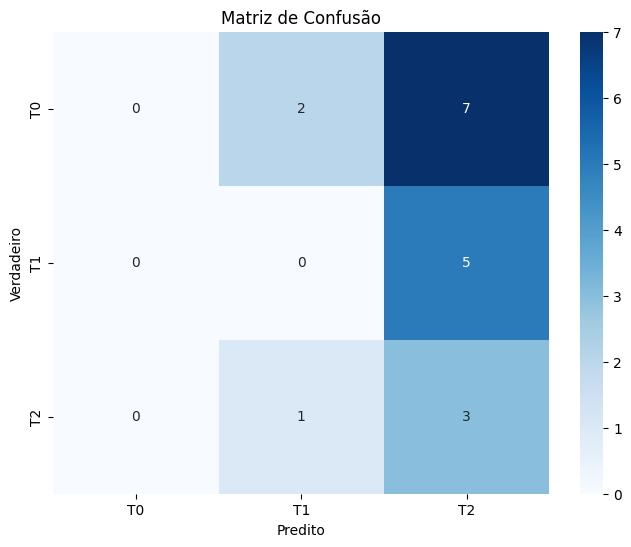

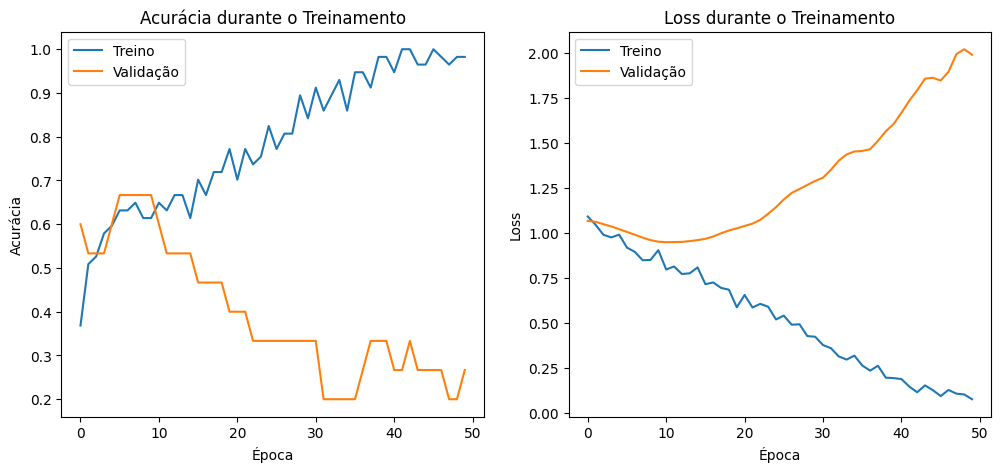

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, LSTM, 
                                    Dense, Dropout, BatchNormalization,
                                    Flatten, Input)
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pyedflib import EdfReader
from pathlib import Path

# Configurações
FS = 160  # Frequência de amostragem
EPOCH_DURATION = 4  # segundos
N_SAMPLES = FS * EPOCH_DURATION
EVENTS = {'T0': 0, 'T1': 1, 'T2': 2}

# Função para processar os arquivos e extrair épocas
def process_file_for_dl(file_path):
    reader = EdfReader(str(file_path))
    
    # Obter sinais
    signal_labels = reader.getSignalLabels()
    c3_idx = signal_labels.index('C3..')
    c4_idx = signal_labels.index('C4..')
    fs = reader.getSampleFrequency(c3_idx)
    signals = np.array([reader.readSignal(i) for i in range(reader.signals_in_file)])
    
    # Obter anotações
    annotations = reader.readAnnotations()
    reader.close()
    
    X, y = [], []
    
    for onset, duration, description in zip(*annotations):
        if description not in EVENTS:
            continue
            
        start = int(onset * fs)
        end = start + N_SAMPLES
        
        if end > signals.shape[1]:
            continue
            
        # Extrair época (C3 e C4 juntos como 2 canais)
        epoch = np.vstack([
            signals[c3_idx, start:end],
            signals[c4_idx, start:end]
        ])
        
        # Normalização por época
        epoch = (epoch - epoch.mean()) / (epoch.std() + 1e-10)
        
        X.append(epoch.T)  # Formato (amostras, canais)
        y.append(EVENTS[description])
    
    return np.array(X), np.array(y)

# Carregar e processar todos os arquivos
pasta = Path('data/phisionet_data/S001')
registros = ['R04', 'R08', 'R12']

X_all, y_all = [], []
for registro in registros:
    edf_file = next(pasta.glob(f'*{registro}.edf'))
    X, y = process_file_for_dl(edf_file)
    X_all.append(X)
    y_all.append(y)

X = np.concatenate(X_all)
y = np.concatenate(y_all)

# Verificar shapes
print(f"Shape dos dados: {X.shape}")  # (n_épocas, 640, 2)
print(f"Shape dos labels: {y.shape}")

# One-hot encoding
y_categorical = to_categorical(y, num_classes=3)

# Dividir dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, stratify=y, random_state=42
)

# Arquitetura CNN-LSTM
def create_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        
        # Bloco convolucional 1
        Conv1D(filters=64, kernel_size=10, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        # Bloco convolucional 2
        Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        # Bloco LSTM
        LSTM(64, return_sequences=True),
        LSTM(32),
        Dropout(0.3),
        
        # Classificação
        Dense(32, activation='relu'),
        Dense(3, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Criar e treinar o modelo
model = create_model((N_SAMPLES, 2))
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

# Avaliação
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

print("\nRelatório de Classificação:")
print(classification_report(y_test_classes, y_pred_classes, target_names=EVENTS.keys()))

# Matriz de confusão
cm = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=EVENTS.keys(), 
            yticklabels=EVENTS.keys())
plt.title('Matriz de Confusão')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.show()

# Curvas de aprendizado
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia durante o Treinamento')
plt.ylabel('Acurácia')
plt.xlabel('Época')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss durante o Treinamento')
plt.ylabel('Loss')
plt.xlabel('Época')
plt.legend()
plt.show()

Processando Sujeitos: 100%|██████████| 109/109 [00:01<00:00, 79.37it/s]

Epoch 1/100


388/394 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4815 - loss: 1.0496

394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4822 - loss: 1.0485 - val_accuracy: 0.5527 - val_loss: 0.9479 - learning_rate: 0.0010
Epoch 2/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5667 - loss: 0.9318

394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5667 - loss: 0.9318 - val_accuracy: 0.5584 - val_loss: 0.9348 - learning_rate: 0.0010
Epoch 3/100
388/394 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5853 - loss: 0.9038

...

394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6481 - loss: 0.7810 - val_accuracy: 0.5877 - val_loss: 0.8707 - learning_rate: 1.0000e-05
Epoch 58/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6597 - loss: 0.7731 - val_accuracy: 0.5883 - val_loss: 0.8707 - learning_rate: 1.0000e-05
Epoch 59/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6503 - loss: 0.7836 - val_accuracy: 0.5877 - val_loss: 0.8709 - learning_rate: 1.0000e-06
Epoch 60/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6647 - loss: 0.7706 - val_accuracy: 0.5877 - val_loss: 0.8707 - learning_rate: 1.0000e-06
Epoch 61/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6415 - loss: 0.7997 - val_accuracy: 0.5896 - val_loss: 0.8707 - learning_rate: 1.0000e-06
Epoch 62/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6623 - loss: 0.7692

394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6622 - loss: 0.7693 - val_accuracy: 0.5883 - val_loss: 0.8706 - learning_rate: 1.0000e-06
Epoch 63/100
390/394 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6509 - loss: 0.7931

394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6509 - loss: 0.7930 - val_accuracy: 0.5889 - val_loss: 0.8706 - learning_rate: 1.0000e-06
Epoch 64/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6534 - loss: 0.7728 - val_accuracy: 0.5877 - val_loss: 0.8707 - learning_rate: 1.0000e-06
Epoch 65/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6556 - loss: 0.7674 - val_accuracy: 0.5877 - val_loss: 0.8708 - learning_rate: 1.0000e-06
Epoch 66/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6613 - loss: 0.7738 - val_accuracy: 0.5870 - val_loss: 0.8707 - learning_rate: 1.0000e-06
Epoch 67/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6479 - loss: 0.7919 - val_accuracy: 0.5858 - val_loss: 0.8707 - learning_rate: 1.0000e-06
Epoch 68/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6520 - loss: 0.7845 - val_accuracy: 0.5864 - val_loss: 0.8709 - learning_rate: 1.0000e-07
Epoch 69/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy:

394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6488 - loss: 0.7911 - val_accuracy: 0.5889 - val_loss: 0.8705 - learning_rate: 1.0000e-08
Epoch 74/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6494 - loss: 0.7875 - val_accuracy: 0.5864 - val_loss: 0.8707 - learning_rate: 1.0000e-08
Epoch 75/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6472 - loss: 0.7926 - val_accuracy: 0.5870 - val_loss: 0.8707 - learning_rate: 1.0000e-08
Epoch 76/100
389/394 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6464 - loss: 0.7929

394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6465 - loss: 0.7927 - val_accuracy: 0.5889 - val_loss: 0.8704 - learning_rate: 1.0000e-08
Epoch 77/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6475 - loss: 0.7888 - val_accuracy: 0.5877 - val_loss: 0.8705 - learning_rate: 1.0000e-08
Epoch 78/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6579 - loss: 0.7835 - val_accuracy: 0.5883 - val_loss: 0.8706 - learning_rate: 1.0000e-08
Epoch 79/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6572 - loss: 0.7801 - val_accuracy: 0.5877 - val_loss: 0.8708 - learning_rate: 1.0000e-08
Epoch 80/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6548 - loss: 0.7794 - val_accuracy: 0.5870 - val_loss: 0.8707 - learning_rate: 1.0000e-08
Epoch 81/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6640 - loss: 0.7752 - val_accuracy: 0.5877 - val_loss: 0.8708 - learning_rate: 1.0000e-08
Epoch 82/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy:

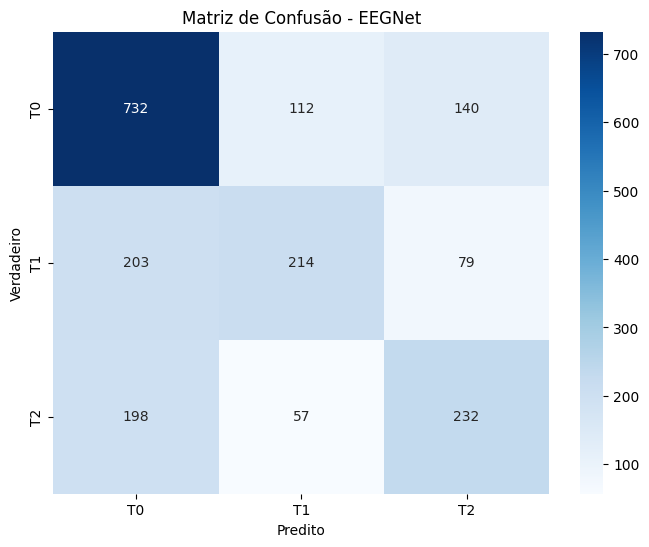

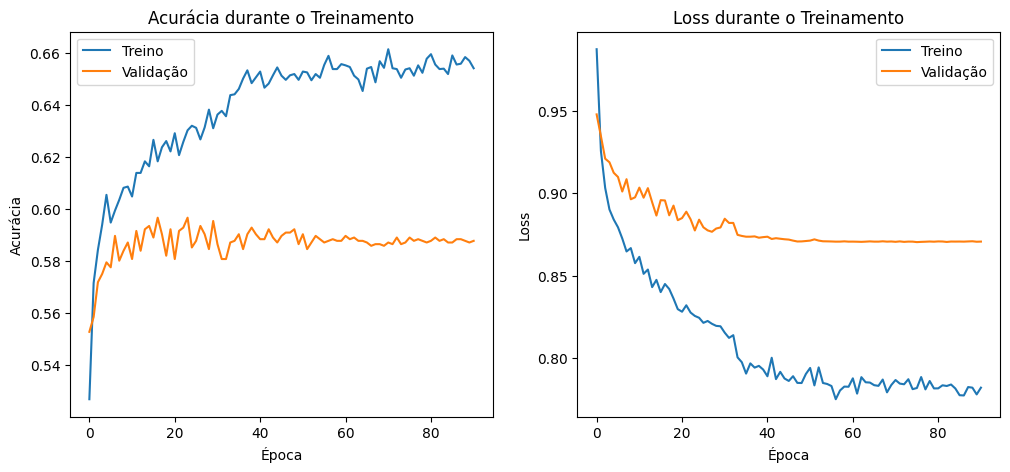

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, 
                                   Activation, DepthwiseConv2D, 
                                   AveragePooling2D, Flatten, Dense, 
                                   Dropout, Reshape)
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pyedflib import EdfReader
from pathlib import Path
from tqdm import tqdm
import os

# Configurações
FS = 160  # Frequência de amostragem
EPOCH_DURATION = 4  # segundos
N_SAMPLES = FS * EPOCH_DURATION
EVENTS = {'T0': 0, 'T1': 1, 'T2': 2}
CHANNELS = ['C3..', 'C4..']  # Canais que usaremos

# Implementação da EEGNet
def EEGNet(input_shape, num_classes):
    input_layer = Input(shape=input_shape)
    
    # Block 1
    x = Conv2D(8, (1, 64), padding='same', use_bias=False)(input_layer)
    x = BatchNormalization()(x)
    x = DepthwiseConv2D((2, 1), depth_multiplier=2, 
                       depthwise_constraint=tf.keras.constraints.max_norm(1.),
                       use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 4))(x)
    x = Dropout(0.25)(x)
    
    # Block 2
    x = Conv2D(16, (1, 16), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 8))(x)
    x = Dropout(0.25)(x)
    
    # Classificador
    x = Flatten()(x)
    x = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs=input_layer, outputs=x)

# Função para processar um arquivo EDF
def process_file(file_path):
    try:
        reader = EdfReader(str(file_path))
        
        # Obter índices dos canais desejados
        signal_labels = reader.getSignalLabels()
        channel_indices = [signal_labels.index(ch) for ch in CHANNELS 
                          if ch in signal_labels]
        if len(channel_indices) != 2:
            reader.close()
            return None, None
            
        fs = reader.getSampleFrequency(channel_indices[0])
        signals = np.array([reader.readSignal(i) for i in channel_indices])
        
        # Obter anotações
        annotations = reader.readAnnotations()
        reader.close()
        
        X, y = [], []
        
        for onset, duration, description in zip(*annotations):
            if description not in EVENTS:
                continue
                
            start = int(onset * fs)
            end = start + N_SAMPLES
            
            if end > signals.shape[1]:
                continue
                
            # Extrair época e normalizar
            epoch = signals[:, start:end]
            epoch = (epoch - epoch.mean(axis=1, keepdims=True)) / (epoch.std(axis=1, keepdims=True) + 1e-10)
            
            X.append(epoch)
            y.append(EVENTS[description])
            
        return np.array(X), np.array(y)
    except:
        return None, None

# Carregar todos os dados
def load_all_data(base_path):
    X_all, y_all = [], []
    
    # Processar todos os sujeitos de S001 a S109
    for subject in tqdm(range(1, 110), desc="Processando Sujeitos"):
        subject_id = f"S{subject:03d}"
        subject_path = base_path / subject_id
        
        if not subject_path.exists():
            continue
            
        # Processar R04, R08 e R12 para cada sujeito
        for session in ['R04', 'R08', 'R12']:
            edf_file = next(subject_path.glob(f'*{session}.edf'), None)
            if edf_file and edf_file.exists():
                X, y = process_file(edf_file)
                if X is not None and len(X) > 0:
                    X_all.append(X)
                    y_all.append(y)
    
    if len(X_all) == 0:
        return None, None
        
    X = np.concatenate(X_all)
    y = np.concatenate(y_all)
    
    # Formatar para EEGNet (amostras, canais, amostras_temporais, 1)
    X = X[:, :, :, np.newaxis]
    
    return X, y

# Carregar os dados
base_path = Path('data/phisionet_data')
X, y = load_all_data(base_path)

if X is None:
    raise ValueError("Nenhum dado válido foi encontrado. Verifique os caminhos dos arquivos.")

# One-hot encoding
y_categorical = to_categorical(y, num_classes=3)

# Dividir os dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, stratify=y, random_state=42
)

# Criar e compilar o modelo
model = EEGNet(input_shape=(2, N_SAMPLES, 1), num_classes=3)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.1, patience=5),
    tf.keras.callbacks.ModelCheckpoint('best_eegnet.h5', save_best_only=True)
]

# Treinar o modelo
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

# Avaliação
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

print("\nRelatório de Classificação:")
print(classification_report(y_test_classes, y_pred_classes, target_names=EVENTS.keys()))

# Matriz de confusão
plt.figure(figsize=(8,6))
sns.heatmap(
    confusion_matrix(y_test_classes, y_pred_classes),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=EVENTS.keys(),
    yticklabels=EVENTS.keys()
)
plt.title('Matriz de Confusão - EEGNet')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.show()

# Curvas de aprendizado
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia durante o Treinamento')
plt.ylabel('Acurácia')
plt.xlabel('Época')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss durante o Treinamento')
plt.ylabel('Loss')
plt.xlabel('Época')
plt.legend()
plt.show()

Processing Subjects: 100%|██████████| 109/109 [00:03<00:00, 33.93it/s]



Using channels: ['C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..']
Data shape: (9835, 7, 640, 1)
Epoch 1/200
392/394 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4085 - loss: 0.4203

394/394 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.4088 - loss: 0.4183 - val_accuracy: 0.5337 - val_loss: 1.0521 - learning_rate: 5.0000e-04
Epoch 2/200
392/394 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5087 - loss: 4.3312e-04

394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5086 - loss: 4.3307e-04 - val_accuracy: 0.5324 - val_loss: 1.0236 - learning_rate: 5.0000e-04
Epoch 3/200
393/394 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4695 - loss: 4.2453e-04

394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4695 - loss: 4.2453e-04 - val_accuracy: 0.4905 - val_loss: 1.0151 - learning_rate: 5.0000e-04
Epoch 4/200
392/394 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4790 - loss: 4.2573e-04

...

394/394 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.6061 - loss: 3.5990e-04 - val_accuracy: 0.6055 - val_loss: 0.8794 - learning_rate: 2.0000e-05
Epoch 80/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6070 - loss: 3.5669e-04 - val_accuracy: 0.5978 - val_loss: 0.8916 - learning_rate: 2.0000e-05
Epoch 81/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6074 - loss: 3.5953e-04 - val_accuracy: 0.6061 - val_loss: 0.8842 - learning_rate: 2.0000e-05
Epoch 82/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6070 - loss: 3.5394e-04 - val_accuracy: 0.5940 - val_loss: 0.8959 - learning_rate: 2.0000e-05
Epoch 83/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5937 - loss: 3.5919e-04 - val_accuracy: 0.6207 - val_loss: 0.8811 - learning_rate: 2.0000e-05
Epoch 84/200
393/394 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6059 - loss: 3.5909e-04

394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6058 - loss: 3.5909e-04 - val_accuracy: 0.6023 - val_loss: 0.8778 - learning_rate: 2.0000e-05
Epoch 85/200
393/394 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6010 - loss: 3.6018e-04

394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6009 - loss: 3.6017e-04 - val_accuracy: 0.6067 - val_loss: 0.8763 - learning_rate: 2.0000e-05
Epoch 86/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5987 - loss: 3.6185e-04 - val_accuracy: 0.6042 - val_loss: 0.8813 - learning_rate: 2.0000e-05
Epoch 87/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5983 - loss: 3.5803e-04 - val_accuracy: 0.5883 - val_loss: 0.9021 - learning_rate: 2.0000e-05
Epoch 88/200
391/394 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5909 - loss: 3.5372e-04

394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5909 - loss: 3.5377e-04 - val_accuracy: 0.6194 - val_loss: 0.8722 - learning_rate: 2.0000e-05
Epoch 89/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6184 - loss: 3.5455e-04 - val_accuracy: 0.5953 - val_loss: 0.8916 - learning_rate: 2.0000e-05
Epoch 90/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5917 - loss: 3.5754e-04 - val_accuracy: 0.6055 - val_loss: 0.8824 - learning_rate: 2.0000e-05
Epoch 91/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6002 - loss: 3.5683e-04 - val_accuracy: 0.6112 - val_loss: 0.8846 - learning_rate: 2.0000e-05
Epoch 92/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6078 - loss: 3.5592e-04 - val_accuracy: 0.5985 - val_loss: 0.8898 - learning_rate: 2.0000e-05
Epoch 93/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6009 - loss: 3.5604e-04 - val_accuracy: 0.5972 - val_loss: 0.8866 - learning_rate: 2.0000e-05
Epoch 94/200
394/394 ━━━━━━━━━━━━━━

394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5839 - loss: 3.5877e-04 - val_accuracy: 0.6017 - val_loss: 0.8722 - learning_rate: 2.0000e-05
Epoch 98/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6046 - loss: 3.5527e-04 - val_accuracy: 0.6004 - val_loss: 0.8794 - learning_rate: 2.0000e-05
Epoch 99/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.6108 - loss: 3.4897e-04 - val_accuracy: 0.6156 - val_loss: 0.8782 - learning_rate: 4.0000e-06
Epoch 100/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.6120 - loss: 3.5002e-04 - val_accuracy: 0.6055 - val_loss: 0.8803 - learning_rate: 4.0000e-06
Epoch 101/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5983 - loss: 3.4710e-04 - val_accuracy: 0.6125 - val_loss: 0.8786 - learning_rate: 4.0000e-06
Epoch 102/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6065 - loss: 3.4438e-04 - val_accuracy: 0.6099 - val_loss: 0.8812 - learning_rate: 4.0000e-06
Epoch 103/200
394/394 ━━━━━━━━━━

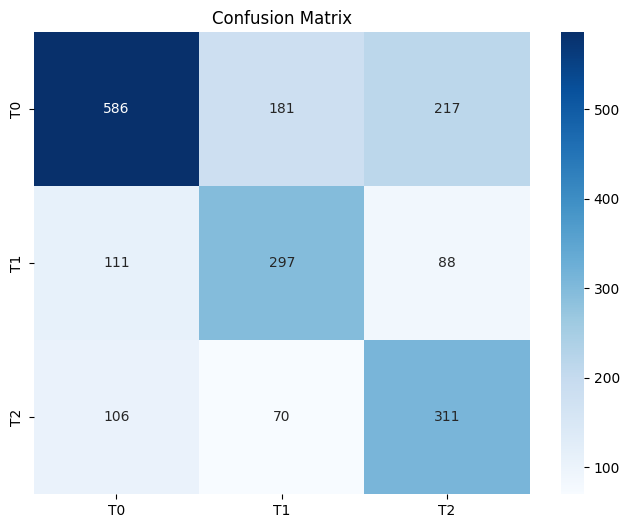

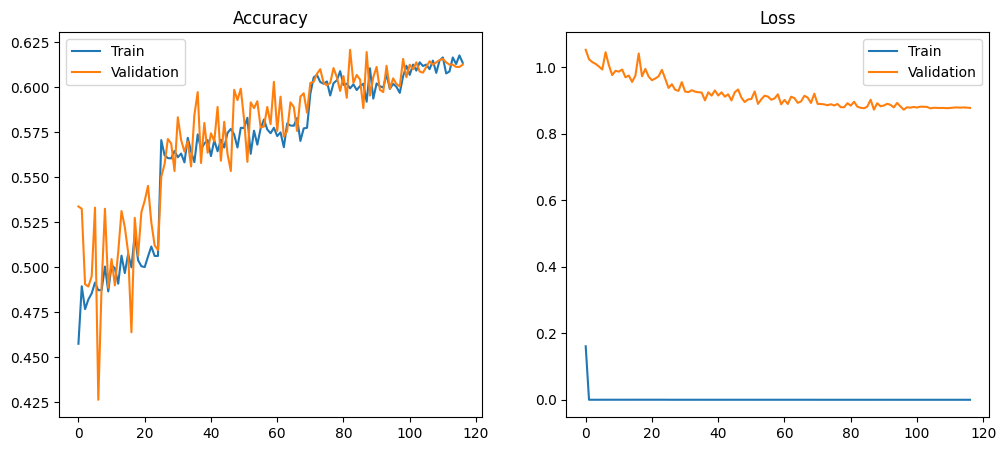

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, 
                                   Activation, DepthwiseConv2D, 
                                   AveragePooling2D, Flatten, Dense, 
                                   Dropout, Reshape, SpatialDropout2D)
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pyedflib import EdfReader
from pathlib import Path
from tqdm import tqdm
import os

# Settings
FS = 160  # Sampling frequency
EPOCH_DURATION = 4  # seconds
N_SAMPLES = FS * EPOCH_DURATION
EVENTS = {'T0': 0, 'T1': 1, 'T2': 2}

# Expanded channel set covering motor and surrounding areas
CHANNELS = [
    'FC3..', 'FC1..', 'FCz..', 'FC2..', 'FC4..',
    'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..',
    'CP3..', 'CP1..', 'CPz..', 'CP2..', 'CP4..'
]

# Enhanced EEGNet architecture
def EEGNet(input_shape, num_classes):
    input_layer = Input(shape=input_shape)
    
    # Block 1 - Temporal and spatial filtering
    x = Conv2D(16, (1, 64), padding='same', use_bias=False)(input_layer)
    x = BatchNormalization()(x)
    x = DepthwiseConv2D((input_shape[0], 1), depth_multiplier=4,
                       depthwise_constraint=tf.keras.constraints.max_norm(1.),
                       use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 4))(x)
    x = SpatialDropout2D(0.4)(x)
    
    # Block 2 - Feature extraction
    x = Conv2D(32, (1, 16), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 8))(x)
    x = SpatialDropout2D(0.4)(x)
    
    # Classifier with regularization
    x = Flatten()(x)
    x = Dense(64, activation='elu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs=input_layer, outputs=output)

def process_file(file_path):
    try:
        reader = EdfReader(str(file_path))
        
        # Get available channels
        signal_labels = reader.getSignalLabels()
        available_channels = [ch for ch in CHANNELS if ch in signal_labels]
        
        if len(available_channels) < 4:  # Minimum 4 channels required
            reader.close()
            return None, None, None
            
        channel_indices = [signal_labels.index(ch) for ch in available_channels]
        fs = reader.getSampleFrequency(channel_indices[0])
        signals = np.array([reader.readSignal(i) for i in channel_indices])
        
        # Get annotations
        annotations = reader.readAnnotations()
        reader.close()
        
        X, y = [], []
        
        for onset, duration, description in zip(*annotations):
            if description not in EVENTS:
                continue
                
            start = int(onset * fs)
            end = start + N_SAMPLES
            
            if end > signals.shape[1]:
                continue
                
            # Extract and normalize epoch
            epoch = signals[:, start:end]
            epoch = (epoch - epoch.mean(axis=1, keepdims=True)) / (epoch.std(axis=1, keepdims=True) + 1e-10)
            
            X.append(epoch)
            y.append(EVENTS[description])
            
        return np.array(X), np.array(y), available_channels
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None, None, None

def load_all_data(base_path):
    X_all, y_all = [], []
    channel_names = None
    
    for subject in tqdm(range(1, 110), desc="Processing Subjects"):
        subject_id = f"S{subject:03d}"
        subject_path = base_path / subject_id
        
        if not subject_path.exists():
            continue
            
        for session in ['R04', 'R08', 'R12']:
            edf_file = next(subject_path.glob(f'*{session}.edf'), None)
            if edf_file and edf_file.exists():
                X, y, channels = process_file(edf_file)
                if X is not None and len(X) > 0:
                    X_all.append(X)
                    y_all.append(y)
                    if channel_names is None:
                        channel_names = channels
    
    if len(X_all) == 0:
        return None, None, None
        
    X = np.concatenate(X_all)
    y = np.concatenate(y_all)
    
    # Format for EEGNet (samples, channels, timepoints, 1)
    X = X[:, :, :, np.newaxis]
    
    return X, y, channel_names

# Main execution
if __name__ == "__main__":
    base_path = Path('data/phisionet_data')
    X, y, channel_names = load_all_data(base_path)
    
    if X is None:
        raise ValueError("No valid data found. Check file paths.")
    
    print(f"\nUsing channels: {channel_names}")
    print(f"Data shape: {X.shape}")
    
    # One-hot encoding and split
    y_categorical = to_categorical(y, num_classes=3)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_categorical, test_size=0.2, stratify=y, random_state=42
    )
    
    # Create and compile model
    model = EEGNet(input_shape=(len(channel_names), N_SAMPLES, 1), num_classes=3)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=10, min_lr=1e-6),
        tf.keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only=True)
    ]
    
    # Train with class weighting
    class_counts = np.sum(y_train, axis=0)
    class_weights = {i: 1./count for i, count in enumerate(class_counts)}
    
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1
    )
    
    # Evaluation
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)
    
    print("\nClassification Report:")
    print(classification_report(y_test_classes, y_pred_classes, target_names=EVENTS.keys()))
    
    # Confusion matrix
    plt.figure(figsize=(8,6))
    sns.heatmap(
        confusion_matrix(y_test_classes, y_pred_classes),
        annot=True, fmt='d', cmap='Blues',
        xticklabels=EVENTS.keys(),
        yticklabels=EVENTS.keys()
    )
    plt.title('Confusion Matrix')
    plt.show()
    
    # Learning curves
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title('Accuracy')
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title('Loss')
    plt.legend()
    plt.show()